In [23]:
import getpass
import os


def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


# _set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

In [2]:
### Retrieval Grader
from models import model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

In [6]:
import chromadb
client = chromadb.PersistentClient(
    path=r"C:\Users\luyer\my_rag\data"
)

In [7]:
collection = client.get_or_create_collection("my_movies")

In [8]:
print("Documents indexed:", collection.count())

Documents indexed: 328


In [9]:
results = collection.query(
    query_texts=["What is the director for Citizen Kane?"],
    n_results=3,
    include=["documents", "metadatas"],
)

for document, metadata in zip(
    results["documents"][0],
    results["metadatas"][0]
):
    
    print("Source:", metadata)
    print(document)
    print("-" * 60)

Source: {'creationdate': '2026-08-25T22:32:40+00:00', 'title': 'Citizen Kane - Wikipedia', 'producer': 'Skia/PDF m151', 'total_pages': 50, 'creator': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/151.0.0.0 Safari/537.36', 'page': 49, 'source': 'C:\\Users\\luyer\\my_rag\\data\\Citizen_Kane.pdf', 'moddate': '2026-08-25T22:32:40+00:00', 'page_label': '50', 'start_index': 0}
Citizen Kane and Bernard Herrmann's film score (http://www.americanmusicpreservation.co
m/CitizenKanefilmscore.htm)
PBS: Citizen Kane (https://www.pbs.org/wgbh/americanexperience/films/kane2/) (Archived)
Bright Lights Film Journal Essay (http://arquivo.pt/wayback/20090713051923/http://www.bri
ghtlightsfilm.com/45/kane.htm)
Roger Ebert: Citizen Kane (https://web.archive.org/web/20120711082553/http://rogerebert.s
untimes.com/apps/pbcs.dll/article?AID=%2F19980524%2FREVIEWS08%2F401010334%2
F1023)
The Unofficial Citizen Kane Page (http://hem.bredband.net/b139242)
Time Magazine Top 10

In [14]:
results

{'ids': [['247', '248', '245']],
 'embeddings': None,
 'documents': [["Citizen Kane and Bernard Herrmann's film score (http://www.americanmusicpreservation.co\nm/CitizenKanefilmscore.htm)\nPBS: Citizen Kane (https://www.pbs.org/wgbh/americanexperience/films/kane2/) (Archived)\nBright Lights Film Journal Essay (http://arquivo.pt/wayback/20090713051923/http://www.bri\nghtlightsfilm.com/45/kane.htm)\nRoger Ebert: Citizen Kane (https://web.archive.org/web/20120711082553/http://rogerebert.s\nuntimes.com/apps/pbcs.dll/article?AID=%2F19980524%2FREVIEWS08%2F401010334%2\nF1023)\nThe Unofficial Citizen Kane Page (http://hem.bredband.net/b139242)\nTime Magazine Top 100 (https://entertainment.time.com/2005/02/12/all-time-100-movies/slid\ne/citizen-kane-1941-2/)\nGreatest films (https://www.filmsite.org/citi.html)\nDVD review (http://www.dvdjournal.com/reviews/c/citizenkane.shtml)",
   'DVD review (http://www.dvdjournal.com/reviews/c/citizenkane.shtml)\n"Scene-by-scene analysis" (https://web.archiv

In [18]:
results['documents']

[["Citizen Kane and Bernard Herrmann's film score (http://www.americanmusicpreservation.co\nm/CitizenKanefilmscore.htm)\nPBS: Citizen Kane (https://www.pbs.org/wgbh/americanexperience/films/kane2/) (Archived)\nBright Lights Film Journal Essay (http://arquivo.pt/wayback/20090713051923/http://www.bri\nghtlightsfilm.com/45/kane.htm)\nRoger Ebert: Citizen Kane (https://web.archive.org/web/20120711082553/http://rogerebert.s\nuntimes.com/apps/pbcs.dll/article?AID=%2F19980524%2FREVIEWS08%2F401010334%2\nF1023)\nThe Unofficial Citizen Kane Page (http://hem.bredband.net/b139242)\nTime Magazine Top 100 (https://entertainment.time.com/2005/02/12/all-time-100-movies/slid\ne/citizen-kane-1941-2/)\nGreatest films (https://www.filmsite.org/citi.html)\nDVD review (http://www.dvdjournal.com/reviews/c/citizenkane.shtml)",
  'DVD review (http://www.dvdjournal.com/reviews/c/citizenkane.shtml)\n"Scene-by-scene analysis" (https://web.archive.org/web/20120422005046/http://www.movie\nmoviesite.com/Films/1941/c

In [3]:
model.invoke("What is the capital of France?")

AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'id': 'msg_011CeW3e3MuX4PystQYHgkT3', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 14, 'output_tokens': 10, 'output_tokens_details': None, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--01a04aca-472d-7f20-934d-d889e219b76f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 10, 'total_tokens': 24, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}})

In [4]:
# Prompt
prompt = PromptTemplate(
    template="""You are a teacher grading a quiz. You will be given: 
    1/ a QUESTION
    2/ A FACT provided by the student
    
    You are grading RELEVANCE RECALL:
    A score of 1 means that ANY of the statements in the FACT are relevant to the QUESTION. 
    A score of 0 means that NONE of the statements in the FACT are relevant to the QUESTION. 
    1 is the highest (best) score. 0 is the lowest score you can give. 
    
    Explain your reasoning in a step-by-step manner. Ensure your reasoning and conclusion are correct. 
    
    Avoid simply stating the correct answer at the outset.
    
    Question: {question} \n
    Fact: \n\n {documents} \n\n
    
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question. \n
    Provide the binary score as a JSON with a single key 'score' and no premable or explanation.
    """,
    input_variables=["question", "documents"],
)

In [5]:
retrieval_grader = prompt | model | JsonOutputParser()

In [16]:
question = "Who is the director of Citizen Kane?"

In [17]:
docs = collection.query(
    query_texts=[question],
    n_results=3,
    include=["documents"]
)['documents']

In [19]:
doc_txt = docs[0][0]
print(retrieval_grader.invoke({"question": question, "documents": doc_txt}))

{'score': 'no'}


In [21]:
import pprint

In [22]:
### Generate

from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = PromptTemplate(
    template="""You are an assistant for question-answering tasks. 
    
    Use the following documents to answer the question. 
    
    If you don't know the answer, just say that you don't know. 
    
    Use three sentences maximum and keep the answer concise:
    Question: {question} 
    Documents: {documents} 
    Answer: 
    """,
    input_variables=["question", "documents"],
)

# LLM
# llm = ChatOllama(model=local_llm, temperature=0)

# Chain
rag_chain = prompt | model | StrOutputParser()

# Run
generation = rag_chain.invoke({"documents": docs, "question": question})
pprint.pprint(generation)

("I don't know. The documents provided contain only links and references to "
 'various Citizen Kane resources, but they do not include the actual content '
 'that states who the director is. To answer this question, I would need '
 "documents that contain information about the film's director.")


In [24]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\luyer\AppData\Local\Temp\ipykernel_26816\730760015.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\luyer\AppData\Local\Temp\ipykernel_26816\730760015.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


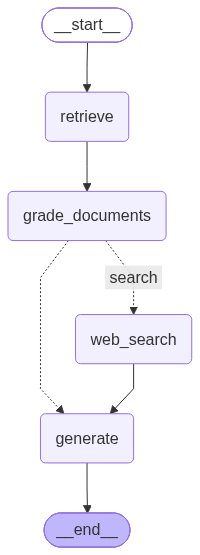

In [27]:
from typing import List
from typing_extensions import TypedDict
from IPython.display import Image, display
from langchain_core.documents import Document
from langgraph.graph import START, END, StateGraph


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    search: str
    documents: List[str]
    steps: List[str]


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    question = state["question"]
    documents = collection.query(
                query_texts=[question],
                n_results=3,
                include=["documents"]
                )['documents'][0]
    
    steps = state["steps"]
    steps.append("retrieve_documents")
    return {"documents": documents, "question": question, "steps": steps}

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke({"documents": documents, "question": question})
    steps = state["steps"]
    steps.append("generate_answer")
    return {
        "documents": documents,
        "question": question,
        "generation": generation,
        "steps": steps,
    }

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    question = state["question"]
    documents = state["documents"]
    steps = state["steps"]
    steps.append("grade_document_retrieval")
    filtered_docs = []
    search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "documents": d}
        )
        grade = score["score"]
        if grade == "yes":
            filtered_docs.append(d)
        else:
            search = "Yes"
            continue
    return {
        "documents": filtered_docs,
        "question": question,
        "search": search,
        "steps": steps,
    }

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    question = state["question"]
    documents = state.get("documents", [])
    steps = state["steps"]
    steps.append("web_search")
    web_results = web_search_tool.invoke({"query": question})
    documents.extend(
        [
            Document(page_content=d["content"], metadata={"url": d["url"]})
            for d in web_results
        ]
    )
    return {"documents": documents, "question": question, "steps": steps}

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    search = state["search"]
    if search == "Yes":
        return "search"
    else:
        return "generate"

# Graph
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("web_search", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "search": "web_search",
        "generate": "generate",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", END)

custom_graph = workflow.compile()

display(Image(custom_graph.get_graph(xray=True).draw_mermaid_png()))

In [29]:
import uuid


def predict_custom_agent_local_answer(example: dict):
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    state_dict = custom_graph.invoke(
        {"question": example["input"], "steps": []}, config
    )
    return {"response": state_dict["generation"], "steps": state_dict["steps"]}


example = {"input": "who directed movie Parasite?"}
response = predict_custom_agent_local_answer(example)
response


{'response': "Bong Joon Ho directed the movie Parasite. He also co-wrote the screenplay with Han Jin-won for this 2019 South Korean black comedy thriller film that won the Palme d'Or at Cannes.",
 'steps': ['retrieve_documents',
  'grade_document_retrieval',
  'web_search',
  'generate_answer']}

### Eval

In [33]:
from langsmith import Client

client = Client()


In [36]:
import pandas as pd

In [37]:
examples = pd.read_csv("C:\\Users\\luyer\\my_rag\\data\\movie_wikipedia_ground_truth.csv").to_dict(orient="records")

In [38]:
examples

[{'id': 1,
  'question': 'How does the article introduce 2001: A Space Odyssey?',
  'answer': '2001: A Space Odyssey is a 1968 epic science fiction film produced and directed by Stanley Kubrick, who co-wrote the screenplay with Arthur C.',
  'source_file': '2001_A_Space_Odyssey.pdf',
  'article_title': '2001: A Space Odyssey',
  'section': 'Overview',
  'page': 1,
  'source_url': 'https://en.wikipedia.org/wiki/2001:_A_Space_Odyssey',
  'answer_type': 'extractive'},
 {'id': 2,
  'question': 'What production detail does the Production section give about 2001: A Space Odyssey?',
  'answer': 'The film is noted for its scientifically accurate depiction of spaceflight, pioneering special effects, and ambiguous themes.',
  'source_file': '2001_A_Space_Odyssey.pdf',
  'article_title': '2001: A Space Odyssey',
  'section': 'Production',
  'page': 1,
  'source_url': 'https://en.wikipedia.org/wiki/2001:_A_Space_Odyssey',
  'answer_type': 'extractive'},
 {'id': 3,
  'question': "What important plo

In [41]:
for example in examples[:10]:
    print((example['id'], example['question'], example['answer'], example['source_file'], example['section']))

(1, 'How does the article introduce 2001: A Space Odyssey?', '2001: A Space Odyssey is a 1968 epic science fiction film produced and directed by Stanley Kubrick, who co-wrote the screenplay with Arthur C.', '2001_A_Space_Odyssey.pdf', 'Overview')
(2, 'What production detail does the Production section give about 2001: A Space Odyssey?', 'The film is noted for its scientifically accurate depiction of spaceflight, pioneering special effects, and ambiguous themes.', '2001_A_Space_Odyssey.pdf', 'Production')
(3, "What important plot event involving the film's characters is described in 2001: A Space Odyssey?", 'When HAL reports the imminent failure of an antenna control device, Bowman retrieves it in an extravehicular activity (EVA) pod, but finds nothing wrong.', '2001_A_Space_Odyssey.pdf', 'Plot')
(4, 'What production detail does the Development section give about 2001: A Space Odyssey?', 'Kubrick obtained financing and distribution from the American studio MGM with the selling point tha

In [45]:
# Save it
dataset_name = "Corrective RAG Agent Movie Testing"
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
else:
    dataset = client.read_dataset(dataset_name=dataset_name)

inputs = [{"input": example['question']} for example in examples]
outputs = [{"output": example['answer']} for example in examples]
metadata = [
    {
        "source_file": example['source_file'],
        "article": example['article_title'],
        "section": example['section'],
        "page": example['page']
    } for example in examples
]
client.create_examples(inputs=inputs, outputs=outputs, metadata=metadata, dataset_id=dataset.id)
print(f"Uploaded {len(examples)} examples to dataset '{dataset_name}'")

Uploaded 100 examples to dataset 'Corrective RAG Agent Movie Testing'
